# BioOS — Biomedical Knowledge Extraction Evaluation

BioOS converts unstructured biomedical research text into structured research objects and relationships using a locally running language model.

This notebook evaluates the extraction component of BioOS on a small, manually annotated biomedical test set.

## Evaluation objectives

We evaluate:

1. **Entity extraction** — whether the correct biomedical objects are identified.
2. **Entity type classification** — whether extracted objects receive the correct BioOS type.
3. **Relationship extraction** — whether relationships between research objects are recovered correctly.
4. **Failure modes** — where and why the extraction pipeline makes mistakes.

The evaluation is intentionally small and interpretable. It is designed as a diagnostic evaluation of the BioOS prototype rather than as a benchmark-scale assessment.

In [36]:
import json
import time

import pandas as pd
import requests


pd.set_option("display.max_colwidth", None)

In [2]:
BIOOS_API = "http://127.0.0.1:8000"

EXTRACT_ENDPOINT = f"{BIOOS_API}/api/extract"

print("BioOS extraction endpoint:", EXTRACT_ENDPOINT)

BioOS extraction endpoint: http://127.0.0.1:8000/api/extract


In [30]:
test_cases = [
    {
        "id": "E01",
        "text": (
            "Duchenne muscular dystrophy is caused by loss of dystrophin. "
            "DMD skeletal muscle shows increased expression of SPP1."
        ),
        "expected_objects": [
            ("Duchenne muscular dystrophy", "Disease"),
            ("dystrophin", "Gene"),
            ("SPP1", "Gene"),
        ],
    },

    {
        "id": "E02",
        "text": (
            "PIK3CA activates the PI3K-AKT signaling pathway. "
            "Alpelisib targets PIK3CA."
        ),
        "expected_objects": [
            ("PIK3CA", "Gene"),
            ("PI3K-AKT signaling pathway", "Pathway"),
            ("Alpelisib", "Drug"),
        ],
    },

    {
        "id": "E03",
        "text": (
            "EGFR is frequently activated in non-small cell lung cancer. "
            "Osimertinib targets mutant EGFR."
        ),
        "expected_objects": [
            ("EGFR", "Gene"),
            ("non-small cell lung cancer", "Disease"),
            ("Osimertinib", "Drug"),
        ],
    },

    {
        "id": "E04",
        "text": (
            "TP53 mutations are common in many cancers and can lead "
            "to impaired DNA damage response."
        ),
        "expected_objects": [
            ("TP53", "Gene"),
            ("DNA damage response", "Pathway"),
        ],
    },

    {
        "id": "E05",
        "text": (
            "HER2 is overexpressed in a subset of breast cancers. "
            "Trastuzumab targets HER2."
        ),
        "expected_objects": [
            ("HER2", "Gene"),
            ("breast cancer", "Disease"),
            ("Trastuzumab", "Drug"),
        ],
    },

    {
        "id": "E06",
        "text": "BRCA1 mutations are associated with hereditary breast cancer.",
        "expected_objects": [
            ("BRCA1", "Gene"),
            ("hereditary breast cancer", "Disease"),
        ],
    },

    {
        "id": "E07",
        "text": "AKT1 regulates the mTOR signaling pathway, which controls cell growth and proliferation.",
        "expected_objects": [
            ("AKT1", "Gene"),
            ("mTOR signaling pathway", "Pathway"),
        ],
    },

    {
        "id": "E08",
        "text": "Metformin is widely used in the treatment of type 2 diabetes mellitus.",
        "expected_objects": [
            ("Metformin", "Drug"),
            ("type 2 diabetes mellitus", "Disease"),
        ],
    },

    {
        "id": "E09",
        "text": "Vemurafenib targets mutant BRAF and inhibits the MAPK signaling pathway.",
        "expected_objects": [
            ("Vemurafenib", "Drug"),
            ("BRAF", "Gene"),
            ("MAPK signaling pathway", "Pathway"),
        ],
    },

    {
        "id": "E10",
        "text": "KRAS mutations activate the MAPK signaling pathway in colorectal cancer, contributing to tumor growth and resistance to targeted therapies.",
        "expected_objects": [
            ("KRAS", "Gene"),
            ("MAPK signaling pathway", "Pathway"),
            ("colorectal cancer", "Disease"),
        ],
    },   
]

len(test_cases)

10

In [16]:
test_df = pd.DataFrame(
    [
        {
            "id": case["id"],
            "text": case["text"],
            "expected_objects": case["expected_objects"],
        }
        for case in test_cases
    ]
)

test_df

,id,text,expected_objects
0,E01,Duchenne muscular dystrophy is caused by loss of dystrophin. DMD skeletal muscle shows increased expression of SPP1.,"[(Duchenne muscular dystrophy, Disease), (dystrophin, Gene), (SPP1, Gene)]"
1,E02,PIK3CA activates the PI3K-AKT signaling pathway. Alpelisib targets PIK3CA.,"[(PIK3CA, Gene), (PI3K-AKT signaling pathway, Pathway), (Alpelisib, Drug)]"
2,E03,EGFR is frequently activated in non-small cell lung cancer. Osimertinib targets mutant EGFR.,"[(EGFR, Gene), (non-small cell lung cancer, Disease), (Osimertinib, Drug)]"
3,E04,TP53 mutations are common in many cancers and can lead to impaired DNA damage response.,"[(TP53, Gene), (DNA damage response, Pathway)]"
4,E05,HER2 is overexpressed in a subset of breast cancers. Trastuzumab targets HER2.,"[(HER2, Gene), (breast cancer, Disease), (Trastuzumab, Drug)]"
5,E06,BRCA1 mutations are associated with hereditary breast cancer.,"[(BRCA1, Gene), (hereditary breast cancer, Disease)]"
6,E07,"AKT1 regulates the mTOR signaling pathway, which controls cell growth and proliferation.","[(AKT1, Gene), (mTOR signaling pathway, Pathway)]"
7,E08,Metformin is widely used in the treatment of type 2 diabetes mellitus.,"[(Metformin, Drug), (type 2 diabetes mellitus, Disease)]"
8,E09,Vemurafenib targets mutant BRAF and inhibits the MAPK signaling pathway.,"[(Vemurafenib, Drug), (BRAF, Gene), (MAPK signaling pathway, Pathway)]"
9,E10,"KRAS mutations activate the MAPK signaling pathway in colorectal cancer, contributing to tumor growth and resistance to targeted therapies.","[(KRAS, Gene), (MAPK signaling pathway, Pathway), (colorectal cancer, Disease)]"


## Run BioOS Extraction

Each evaluation example is submitted to the same `/api/extract` endpoint used by the BioOS frontend.

The returned research objects are stored for comparison with the manually annotated expected objects. Automatically generated `Paper` objects are excluded from entity-level evaluation.

In [17]:
def extract_with_bioos(text):
    """Send biomedical text to the BioOS extraction API."""

    response = requests.post(
        EXTRACT_ENDPOINT,
        json={"text": text},
        timeout=180,
    )

    response.raise_for_status()

    return response.json()

In [18]:
test_result = extract_with_bioos(test_cases[0]["text"])

print(json.dumps(test_result, indent=2))

{
  "title": "DMD and SPP1 Expression",
  "objects": [
    {
      "tempId": "o1",
      "type": "Disease",
      "name": "Duchenne muscular dystrophy",
      "summary": "A genetic disorder characterized by muscle weakness."
    },
    {
      "tempId": "o2",
      "type": "Gene",
      "name": "dystrophin",
      "summary": "A protein essential for maintaining muscle fiber integrity."
    },
    {
      "tempId": "o3",
      "type": "Gene",
      "name": "SPP1",
      "summary": "A secreted phosphoprotein involved in inflammation and fibrosis."
    }
  ],
  "relationships": []
}


In [19]:
results = []

for case in test_cases:
    print(f"Running {case['id']}...", end=" ")

    start = time.time()

    try:
        prediction = extract_with_bioos(case["text"])
        elapsed = time.time() - start

        results.append({
            "id": case["id"],
            "text": case["text"],
            "expected_objects": case["expected_objects"],
            "prediction": prediction,
            "latency_seconds": elapsed,
            "error": None,
        })

        print(f"done ({elapsed:.1f}s)")

    except Exception as exc:
        elapsed = time.time() - start

        results.append({
            "id": case["id"],
            "text": case["text"],
            "expected_objects": case["expected_objects"],
            "prediction": None,
            "latency_seconds": elapsed,
            "error": str(exc),
        })

        print(f"FAILED: {exc}")

Running E01... done (25.1s)
Running E02... done (28.0s)
Running E03... done (24.8s)
Running E04... done (21.7s)
Running E05... done (24.5s)
Running E06... done (20.2s)
Running E07... done (25.9s)
Running E08... done (19.5s)
Running E09... done (24.3s)
Running E10... done (28.3s)


In [20]:
def get_predicted_objects(prediction):
    """
    Return extracted BioOS objects as (name, type) tuples.

    Paper objects are excluded because they are generated by BioOS
    as document-level metadata rather than extracted biomedical entities.
    """

    if prediction is None:
        return []

    return [
        (obj["name"], obj["type"])
        for obj in prediction.get("objects", [])
        if obj["type"] != "Paper"
    ]

In [21]:
for result in results:
    result["predicted_objects"] = get_predicted_objects(
        result["prediction"]
    )

In [22]:
comparison_df = pd.DataFrame(
    [
        {
            "id": result["id"],
            "expected": result["expected_objects"],
            "predicted": result["predicted_objects"],
            "latency_s": round(result["latency_seconds"], 2),
            "error": result["error"],
        }
        for result in results
    ]
)

comparison_df

,id,expected,predicted,latency_s,error
0,E01,"[(Duchenne muscular dystrophy, Disease), (dystrophin, Gene), (SPP1, Gene)]","[(Duchenne muscular dystrophy, Disease), (dystrophin, Gene), (SPP1, Gene)]",25.06,None
1,E02,"[(PIK3CA, Gene), (PI3K-AKT signaling pathway, Pathway), (Alpelisib, Drug)]","[(PIK3CA, Gene), (Alpelisib, Drug)]",28.00,None
2,E03,"[(EGFR, Gene), (non-small cell lung cancer, Disease), (Osimertinib, Drug)]","[(EGFR, Gene), (Osimertinib, Drug)]",24.77,None
3,E04,"[(TP53, Gene), (DNA damage response, Pathway)]","[(TP53, Gene)]",21.72,None
4,E05,"[(HER2, Gene), (breast cancer, Disease), (Trastuzumab, Drug)]","[(HER2, Gene), (Trastuzumab, Drug)]",24.51,None
5,E06,"[(BRCA1, Gene), (hereditary breast cancer, Disease)]","[(BRCA1, Gene)]",20.21,None
6,E07,"[(AKT1, Gene), (mTOR signaling pathway, Pathway)]","[(AKT1, Gene), (mTOR signaling pathway, Pathway)]",25.94,None
7,E08,"[(Metformin, Drug), (type 2 diabetes mellitus, Disease)]","[(Metformin, Drug)]",19.53,None
8,E09,"[(Vemurafenib, Drug), (BRAF, Gene), (MAPK signaling pathway, Pathway)]","[(Vemurafenib, Drug), (BRAF, Gene)]",24.33,None
9,E10,"[(KRAS, Gene), (MAPK signaling pathway, Pathway), (colorectal cancer, Disease)]","[(KRAS, Gene), (MAPK signaling pathway, Pathway)]",28.31,None


## Entity Extraction Evaluation

Predicted biomedical objects are compared against the manually annotated
gold-standard objects using case-insensitive exact-name matching.

Paper objects are excluded because they are generated by BioOS as
document-level metadata rather than extracted biomedical entities.

Precision, recall, and F1 are calculated at the entity level.

In [23]:
def normalize_name(name):
    """Normalize entity names for exact-match evaluation."""
    return " ".join(name.lower().strip().split())


def entity_names(objects):
    """Return normalized entity names while ignoring their types."""
    return {
        normalize_name(name)
        for name, _ in objects
    }

In [24]:
evaluation_rows = []

for result in results:
    expected = entity_names(result["expected_objects"])
    predicted = entity_names(result["predicted_objects"])

    tp = len(expected & predicted)
    fp = len(predicted - expected)
    fn = len(expected - predicted)

    evaluation_rows.append({
        "id": result["id"],
        "TP": tp,
        "FP": fp,
        "FN": fn,
    })

entity_eval_df = pd.DataFrame(evaluation_rows)

entity_eval_df

,id,TP,FP,FN
0,E01,3,0,0
1,E02,2,0,1
2,E03,2,0,1
3,E04,1,0,1
4,E05,2,0,1
5,E06,1,0,1
6,E07,2,0,0
7,E08,1,0,1
8,E09,2,0,1
9,E10,2,0,1


In [25]:
total_tp = entity_eval_df["TP"].sum()
total_fp = entity_eval_df["FP"].sum()
total_fn = entity_eval_df["FN"].sum()

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall)
    else 0
)

print(f"True positives : {total_tp}")
print(f"False positives: {total_fp}")
print(f"False negatives: {total_fn}")
print()
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 score:  {f1:.3f}")

True positives : 18
False positives: 0
False negatives: 8

Precision: 1.000
Recall:    0.692
F1 score:  0.818


In [26]:
additional_test_cases = [
    {
        "id": "E06",
        "text": "BRCA1 mutations are associated with hereditary breast cancer.",
        "expected_objects": [
            ("BRCA1", "Gene"),
            ("hereditary breast cancer", "Disease"),
        ],
    },
    {
        "id": "E07",
        "text": "AKT1 regulates the mTOR signaling pathway, which controls cell growth and proliferation.",
        "expected_objects": [
            ("AKT1", "Gene"),
            ("mTOR signaling pathway", "Pathway"),
        ],
    },
    {
        "id": "E08",
        "text": "Metformin is widely used in the treatment of type 2 diabetes mellitus.",
        "expected_objects": [
            ("Metformin", "Drug"),
            ("type 2 diabetes mellitus", "Disease"),
        ],
    },
    {
        "id": "E09",
        "text": "Vemurafenib targets mutant BRAF and inhibits the MAPK signaling pathway.",
        "expected_objects": [
            ("Vemurafenib", "Drug"),
            ("BRAF", "Gene"),
            ("MAPK signaling pathway", "Pathway"),
        ],
    },
    {
        "id": "E10",
        "text": "KRAS mutations activate the MAPK signaling pathway in colorectal cancer, contributing to tumor growth and resistance to targeted therapies.",
        "expected_objects": [
            ("KRAS", "Gene"),
            ("MAPK signaling pathway", "Pathway"),
            ("colorectal cancer", "Disease"),
        ],
    },
]

test_cases.extend(additional_test_cases)

df = pd.DataFrame(additional_test_cases)
df

,id,text,expected_objects
0,E06,BRCA1 mutations are associated with hereditary breast cancer.,"[(BRCA1, Gene), (hereditary breast cancer, Disease)]"
1,E07,"AKT1 regulates the mTOR signaling pathway, which controls cell growth and proliferation.","[(AKT1, Gene), (mTOR signaling pathway, Pathway)]"
2,E08,Metformin is widely used in the treatment of type 2 diabetes mellitus.,"[(Metformin, Drug), (type 2 diabetes mellitus, Disease)]"
3,E09,Vemurafenib targets mutant BRAF and inhibits the MAPK signaling pathway.,"[(Vemurafenib, Drug), (BRAF, Gene), (MAPK signaling pathway, Pathway)]"
4,E10,"KRAS mutations activate the MAPK signaling pathway in colorectal cancer, contributing to tumor growth and resistance to targeted therapies.","[(KRAS, Gene), (MAPK signaling pathway, Pathway), (colorectal cancer, Disease)]"


## Performance by Object Type

Overall metrics can hide systematic differences between research object
types. We therefore calculate precision, recall, and F1 score separately
for genes, drugs, pathways, and diseases.

In [28]:
OBJECT_TYPES = ["Gene", "Drug", "Pathway", "Disease"]

type_metrics = []

for object_type in OBJECT_TYPES:
    tp = fp = fn = 0

    for _, row in comparison_df.iterrows():
        expected = set(row["expected"])
        predicted = set(row["predicted"])

        expected_type = {
            (name, obj_type)
            for name, obj_type in expected
            if obj_type == object_type
        }

        predicted_type = {
            (name, obj_type)
            for name, obj_type in predicted
            if obj_type == object_type
        }

        tp += len(expected_type & predicted_type)
        fp += len(predicted_type - expected_type)
        fn += len(expected_type - predicted_type)

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall)
        else 0
    )

    type_metrics.append({
        "object_type": object_type,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })

type_metrics_df = pd.DataFrame(type_metrics)

type_metrics_df.round(3)

,object_type,TP,FP,FN,precision,recall,f1
0,Gene,10,0,0,1.0,1.000,1.000
1,Drug,5,0,0,1.0,1.000,1.000
2,Pathway,2,0,3,1.0,0.400,0.571
3,Disease,1,0,5,1.0,0.167,0.286


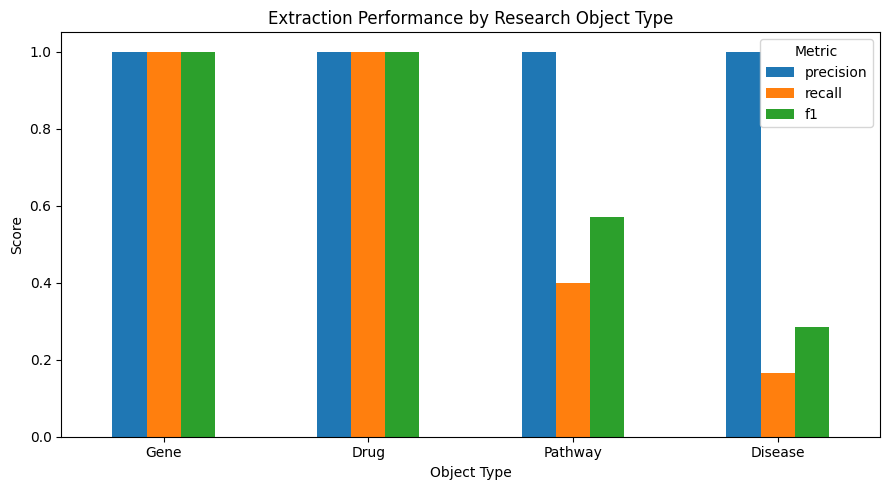

In [29]:
import matplotlib.pyplot as plt

plot_df = type_metrics_df.set_index("object_type")

ax = plot_df[["precision", "recall", "f1"]].plot(
    kind="bar",
    figsize=(9, 5),
    ylim=(0, 1.05)
)

ax.set_title("Extraction Performance by Research Object Type")
ax.set_xlabel("Object Type")
ax.set_ylabel("Score")
ax.legend(title="Metric")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Baseline observations

The baseline extractor achieved perfect precision across all evaluated
object types, indicating that the model produced no spurious entities in
this benchmark. However, recall varied substantially between object
categories.

Gene and drug extraction achieved complete recall in the test set,
whereas pathway recall was 0.40 and disease recall was only 0.167.
Consequently, the lower overall recall of the extraction system is
primarily attributable to omitted disease and pathway entities rather
than incorrect gene or drug predictions.

These results suggest that the baseline extraction strategy is
conservative: extracted objects are generally correct, but some
biologically relevant object types are frequently omitted. Because this
evaluation uses a small, manually constructed benchmark, the results
should be interpreted as a diagnostic analysis rather than as estimates
of general model performance.

## Failure Analysis

To understand the source of extraction errors, we inspect the entities
that were expected but not returned by the baseline extractor.

This analysis helps distinguish systematic object-type weaknesses from
isolated extraction failures.

In [32]:
failure_rows = []

for _, row in comparison_df.iterrows():
    expected = set(row["expected"])
    predicted = set(row["predicted"])

    missed = expected - predicted
    extra = predicted - expected

    if missed or extra:
        failure_rows.append({
            "id": row["id"],
            "missed_entities": list(missed),
            "extra_entities": list(extra)
        })

failure_df = pd.DataFrame(failure_rows)

failure_df

,id,missed_entities,extra_entities
0,E02,"[(PI3K-AKT signaling pathway, Pathway)]",[]
1,E03,"[(non-small cell lung cancer, Disease)]",[]
2,E04,"[(DNA damage response, Pathway)]",[]
3,E05,"[(breast cancer, Disease)]",[]
4,E06,"[(hereditary breast cancer, Disease)]",[]
5,E08,"[(type 2 diabetes mellitus, Disease)]",[]
6,E09,"[(MAPK signaling pathway, Pathway)]",[]
7,E10,"[(colorectal cancer, Disease)]",[]


### Failure pattern

All observed extraction errors were false negatives; no unexpected
entities were produced by the model.

The eight missed entities consisted entirely of disease and pathway
objects: five diseases and three pathways. No gene or drug entities were
missed in this benchmark.

This suggests that the primary limitation of the baseline extraction
configuration is not entity hallucination, but selective under-extraction
of particular semantic categories. Disease entities were especially
affected, consistent with the low disease recall observed in the
object-type analysis.

These findings motivate targeted improvements to the extraction prompt
or extraction pipeline rather than simply replacing the model or
increasing output permissiveness.

## Relationship Extraction Evaluation

BioOS represents extracted research objects as a graph, making relationship
extraction an important component of the pipeline in addition to entity
recognition.

To evaluate relationship extraction independently from the entity-recall
limitations identified above, this benchmark uses explicit biological
relationships between object types that the baseline extractor reliably
recognizes.

In [33]:
relationship_test_cases = [
    {
        "id": "R01",
        "text": "Alpelisib targets PIK3CA."
    },
    {
        "id": "R02",
        "text": "Osimertinib targets EGFR."
    },
    {
        "id": "R03",
        "text": "Trastuzumab targets HER2."
    },
    {
        "id": "R04",
        "text": "PIK3CA activates the PI3K-AKT signaling pathway."
    },
    {
        "id": "R05",
        "text": "Vemurafenib targets BRAF."
    }
]

In [39]:
relationship_results = []

for case in relationship_test_cases:
    start = time.time()

    try:
        response = requests.post(
            EXTRACT_ENDPOINT,
            json={"text": case["text"]},
            timeout=120
        )

        response.raise_for_status()
        data = response.json()

        latency = time.time() - start

        relationship_results.append({
            "id": case["id"],
            "text": case["text"],
            "objects": data.get("objects", []),
            "relationships": data.get("relationships", []),
            "latency_s": round(latency, 2),
            "error": None
        })

    except Exception as e:
        relationship_results.append({
            "id": case["id"],
            "text": case["text"],
            "objects": [],
            "relationships": [],
            "latency_s": None,
            "error": str(e)
        })

relationship_results_df = pd.DataFrame(relationship_results)

relationship_results_df

,id,text,objects,relationships,latency_s,error
0,R01,Alpelisib targets PIK3CA.,"[{'tempId': 'o1', 'type': 'Drug', 'name': 'Alpelisib', 'summary': 'Alpelisib is a drug used in cancer treatment.'}, {'tempId': 'o2', 'type': 'Gene', 'name': 'PIK3CA', 'summary': 'PIK3CA encodes the p110alpha catalytic subunit of PI3K.'}]","[{'from': 'o1', 'to': 'o2', 'type': 'TARGETS'}]",25.15,None
1,R02,Osimertinib targets EGFR.,"[{'tempId': 'o1', 'type': 'Drug', 'name': 'Osimertinib', 'summary': 'A tyrosine kinase inhibitor used in cancer treatment.'}, {'tempId': 'o2', 'type': 'Gene', 'name': 'EGFR', 'summary': 'Epidermal growth factor receptor, a protein involved in cell signaling.'}]","[{'from': 'o1', 'to': 'o2', 'type': 'TARGETS'}]",24.42,None
2,R03,Trastuzumab targets HER2.,"[{'tempId': 'o1', 'type': 'Drug', 'name': 'Trastuzumab', 'summary': 'A monoclonal antibody used in cancer treatment.'}, {'tempId': 'o2', 'type': 'Gene', 'name': 'HER2', 'summary': 'A receptor tyrosine kinase involved in cell growth and differentiation.'}]","[{'from': 'o1', 'to': 'o2', 'type': 'TARGETS'}]",24.02,None
3,R04,PIK3CA activates the PI3K-AKT signaling pathway.,"[{'tempId': 'o1', 'type': 'Gene', 'name': 'PIK3CA', 'summary': 'PIK3CA is a gene encoding a lipid kinase.'}]",[],23.13,None
4,R05,Vemurafenib targets BRAF.,"[{'tempId': 'o1', 'type': 'Drug', 'name': 'Vemurafenib', 'summary': 'A drug used in the treatment of melanoma.'}, {'tempId': 'o2', 'type': 'Gene', 'name': 'BRAF', 'summary': 'A protein involved in cell signaling pathways.'}]","[{'from': 'o1', 'to': 'o2', 'type': 'TARGETS'}]",23.68,None


In [40]:
def resolve_relationships(objects, relationships):
    id_to_name = {
        obj["tempId"]: obj["name"]
        for obj in objects
    }

    resolved = []

    for rel in relationships:
        source = id_to_name.get(rel["from"], rel["from"])
        target = id_to_name.get(rel["to"], rel["to"])

        resolved.append(
            (source, rel["type"], target)
        )

    return resolved

In [41]:
relationship_results_df["resolved_relationships"] = (
    relationship_results_df.apply(
        lambda row: resolve_relationships(
            row["objects"],
            row["relationships"]
        ),
        axis=1
    )
)

relationship_results_df[
    ["id", "text", "resolved_relationships", "latency_s"]
]

,id,text,resolved_relationships,latency_s
0,R01,Alpelisib targets PIK3CA.,"[(Alpelisib, TARGETS, PIK3CA)]",25.15
1,R02,Osimertinib targets EGFR.,"[(Osimertinib, TARGETS, EGFR)]",24.42
2,R03,Trastuzumab targets HER2.,"[(Trastuzumab, TARGETS, HER2)]",24.02
3,R04,PIK3CA activates the PI3K-AKT signaling pathway.,[],23.13
4,R05,Vemurafenib targets BRAF.,"[(Vemurafenib, TARGETS, BRAF)]",23.68


In [42]:
expected_relationships = {
    "R01": [("Alpelisib", "TARGETS", "PIK3CA")],
    "R02": [("Osimertinib", "TARGETS", "EGFR")],
    "R03": [("Trastuzumab", "TARGETS", "HER2")],
    "R04": [("PIK3CA", "ACTIVATES", "PI3K-AKT signaling pathway")],
    "R05": [("Vemurafenib", "TARGETS", "BRAF")]
}

In [43]:
relationship_scores = []

for _, row in relationship_results_df.iterrows():
    expected = set(expected_relationships[row["id"]])
    predicted = set(row["resolved_relationships"])

    tp = len(expected & predicted)
    fp = len(predicted - expected)
    fn = len(expected - predicted)

    relationship_scores.append({
        "id": row["id"],
        "TP": tp,
        "FP": fp,
        "FN": fn
    })

relationship_scores_df = pd.DataFrame(relationship_scores)

relationship_scores_df

,id,TP,FP,FN
0,R01,1,0,0
1,R02,1,0,0
2,R03,1,0,0
3,R04,0,0,1
4,R05,1,0,0


In [44]:
rel_tp = relationship_scores_df["TP"].sum()
rel_fp = relationship_scores_df["FP"].sum()
rel_fn = relationship_scores_df["FN"].sum()

rel_precision = rel_tp / (rel_tp + rel_fp) if (rel_tp + rel_fp) else 0
rel_recall = rel_tp / (rel_tp + rel_fn) if (rel_tp + rel_fn) else 0
rel_f1 = (
    2 * rel_precision * rel_recall / (rel_precision + rel_recall)
    if (rel_precision + rel_recall)
    else 0
)

print(f"True positives : {rel_tp}")
print(f"False positives: {rel_fp}")
print(f"False negatives: {rel_fn}")
print()
print(f"Precision: {rel_precision:.3f}")
print(f"Recall:    {rel_recall:.3f}")
print(f"F1 score:  {rel_f1:.3f}")

True positives : 4
False positives: 0
False negatives: 1

Precision: 1.000
Recall:    0.800
F1 score:  0.889


In [45]:
relationship_failure_analysis = []

for _, row in relationship_results_df.iterrows():
    expected = expected_relationships[row["id"]]

    object_names = {
        obj["name"].lower()
        for obj in row["objects"]
    }

    for source, relation, target in expected:
        source_found = source.lower() in object_names
        target_found = target.lower() in object_names

        predicted = (
            source,
            relation,
            target
        ) in row["resolved_relationships"]

        if not predicted:
            if not source_found or not target_found:
                failure_type = "Entity extraction failure"
            else:
                failure_type = "Relationship extraction failure"

            relationship_failure_analysis.append({
                "id": row["id"],
                "expected_relationship": f"{source} → {relation} → {target}",
                "source_extracted": source_found,
                "target_extracted": target_found,
                "failure_type": failure_type
            })

relationship_failure_df = pd.DataFrame(
    relationship_failure_analysis
)

relationship_failure_df

,id,expected_relationship,source_extracted,target_extracted,failure_type
0,R04,PIK3CA → ACTIVATES → PI3K-AKT signaling pathway,True,False,Entity extraction failure


## Evaluation Summary

BioOS was evaluated on a small manually curated biomedical benchmark covering genes, drugs, diseases, pathways, and relationships.

### Entity extraction

| Metric | Score |
|---|---:|
| Precision | 1.000 |
| Recall | 0.692 |
| F1 | 0.818 |

Performance varied substantially by object type:

| Object type | Precision | Recall | F1 |
|---|---:|---:|---:|
| Gene | 1.000 | 1.000 | 1.000 |
| Drug | 1.000 | 1.000 | 1.000 |
| Pathway | 1.000 | 0.400 | 0.571 |
| Disease | 1.000 | 0.167 | 0.286 |

The extractor showed high precision but conservative recall. Genes and drugs were extracted reliably, while diseases and pathways accounted for most false negatives.

### Relationship extraction

| Metric | Score |
|---|---:|
| Precision | 1.000 |
| Recall | 0.800 |
| F1 | 0.889 |

Four of five expected relationships were recovered. The single missed relationship — `PIK3CA → ACTIVATES → PI3K-AKT signaling pathway` — resulted from failure to extract the pathway object rather than failure to identify the relationship itself.

### Interpretation

These results suggest that the current extraction pipeline prioritizes precision over recall. This is desirable for a research knowledge graph, where introducing unsupported entities or relationships can be more damaging than occasionally omitting an entity.

The primary limitation is entity recall, particularly for Disease and Pathway objects. Because relationships can only be constructed between extracted objects, these upstream omissions also limit downstream graph completeness.

The benchmark is intentionally small and is intended as a lightweight engineering evaluation rather than a comprehensive assessment of biomedical information extraction performance.